In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import time
from functools import wraps
from google.colab import files
from datetime import datetime
from typing import Callable
from typing import Union

# --- 1. UPLOAD FILE ---
print("UPLOAD DATA")
print("Gojek Playstore Reviews by Dewana Kretarta L ")

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Shape Awal : {df.shape} ")


UPLOAD DATA
Gojek Playstore Reviews by Dewana Kretarta L 


Saving gojek.csv to gojek.csv


/tmp/ipykernel_415/2964208564.py:19: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.BytesIO(uploaded[filename]))


Shape Awal : (1674777, 11) 


In [44]:
print(f"Shape Awal : {df.shape} ")
display(df.head(5))

Shape Awal : (1674777, 11) 


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,31afe72f-ef3a-490b-9ddd-3406d8bc6014,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok bgt aplikasinya membantu sy pas lg lapar sk...,5,0,5.49.1,2026-02-27 08:21:14,NaN,NaN,5.49.1
1,91dfef24-809b-4b17-b4a2-f854ab518b79,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aku udah ke sekian kali ga sengaja ke order, t...",3,0,5.50.1,2026-02-27 08:21:04,"Hai Kak Nur Husna, mohon maaf atas ketidaknyam...",2026-02-27 09:11:51,5.50.1
2,d2b6c58f-05e7-4c8c-ad1b-dea72d1f638b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,NaN,2026-02-27 08:05:47,NaN,NaN,NaN
3,318c79ee-e911-4fb5-9e35-695a0443519d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"jangan di download ya guyss, mentang mentang a...",1,0,5.50.1,2026-02-27 08:03:04,NaN,NaN,5.50.1
4,db94eaa2-1eca-46d6-afc6-a93e2f5a1e13,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,5.50.1,2026-02-27 07:58:51,NaN,NaN,5.50.1


In [107]:
#CLEANING DATA

def bersihkan_teks(teks: Union[str, float]) -> str:
    if pd.isna(teks): return ""
    return str(teks).lower().strip()

# Define critical keywords for sentiment classification
KATA_KRITIS_NEGATIF = [
    'parah', 'buruk', 'jelek', 'gagal', 'susah', 'ngecewain',
    'kecewa', 'bangke', 'sampah', 'payah', '😡', '🤬', '👎'
]
KATA_KRITIS_POSITIF = [
    'cepat', 'mudah', 'praktis', 'bagus', 'bantu', 'baik', 'oke',
    'mantap', 'memuaskan', 'sangat membantu', 'terbaik', 'senang',
    '😍', '🥰', '👍', '🚀', '🫶🏻', '🙌🏻', '🫰'
]

def klasifikasi_sentimen_cerdas(baris: pd.Series) -> str:
    try:
        skor = int(baris['score'])
        teks = str(baris['content']).lower()
    except:
        return 'Unknown'

    # OVERRIDE NEGATIF (Prioritas Sarkasme/Marah)
    if any(kritis in teks for kritis in KATA_KRITIS_NEGATIF):
        return 'Negatif (Kritis)'
    # OVERRIDE POSITIF (Prioritas Apresiasi Tinggi)
    if any(kritis in teks for kritis in KATA_KRITIS_POSITIF):
        return 'Positif (Apresiasi)'

    # DEFAULT (scoring)
    if skor <= 2: return 'Negatif'
    elif skor == 3: return 'Netral'
    else: return 'Positif'

def parsing_tanggal(str_date: str) -> str:
    try:
        dt = datetime.strptime(str(str_date), "%Y-%m-%d %H:%M:%S")
        return dt.strftime("%Y-%m")
    except: return "Unknown"

In [109]:
# DECORATOR Monitoring Waktu Eksekusi

def ukur_durasi(fungsi: Callable) -> Callable:
    @wraps(fungsi)
    def wrapper(*args, **kwargs):
        start = time.time()
        print(f"\n[START] Menjalankan: '{fungsi.__name__}'...")
        hasil = fungsi(*args, **kwargs)
        end = time.time()
        print(f"[DONE] Selesai dalam: {end - start:.4f} detik.")
        return hasil
    return wrapper

# CLOSURE ADVANCED (Mendukung banyak kata sekaligus dengan Regex)
def buat_filter_keyword(*keywords: str) -> Callable:
    pola_pencarian = '|'.join(keywords)
    def filter_logika(dataset: pd.DataFrame) -> pd.DataFrame:
        return dataset[dataset['content'].str.contains(pola_pencarian, regex=True, na=False)]
    return filter_logika

# HOF 3: CLOSURE (Pabrik Aturan Sentimen - Indentasi Rapi)
def buat_klasifikator_sentimen(batas_bawah: int, batas_atas: int) -> Callable:
    def klasifikasi(skor) -> str:
        try:
            s = int(skor)
            if s <= batas_bawah: return 'Negatif'
            elif s >= batas_atas: return 'Positif'
            else: return 'Netral'
        except:
            return 'Unknown'
    return klasifikasi



In [47]:
# DEFINE data clean
df_clean = (
    df.copy()
    .assign(
        content = lambda df: df['content'].apply(bersihkan_teks),
        at      = lambda df: df['at'].apply(parsing_tanggal),
        # Menerapkan sentiment cerdas kritis
        score_label = lambda df: df.apply(klasifikasi_sentimen_cerdas, axis=1)
    )
)

In [48]:
df_clean['at'] = pd.to_datetime(df_clean['at'], errors='coerce')

df_2025 = (
    df_clean[df_clean['at'].dt.year == 2025]
    .copy()
    .assign(
        bulan_nama = lambda df: df['at'].dt.strftime('%B'),
        bulan_angka = lambda df: df['at'].dt.to_period('M')
    )
)

print(f"Total Data 2025: {len(df_2025)} baris.")
display(df_2025[['at', 'bulan_nama', 'content', 'score']].head(3))

Total Data 2025: 54660 baris.


,at,bulan_nama,content,score
7679,2025-12-01,December,bagus,5
7680,2025-12-01,December,nice bgt pokoknya,5
7681,2025-12-01,December,sangat baik,5


In [49]:
display(df_clean[['at', 'content', 'score']].head(5))

,at,content,score
0,2026-02-01,ok bgt aplikasinya membantu sy pas lg lapar sk...,5
1,2026-02-01,"aku udah ke sekian kali ga sengaja ke order, t...",3
2,2026-02-01,sangat membantu,5
3,2026-02-01,"jangan di download ya guyss, mentang mentang a...",1
4,2026-02-01,good,5


**HOF**

In [59]:
# MAPPING (DATA 2025)

# Parsing Bulan (Mapping Kolom Baru untuk Kebutuhan Laporan)
df_2025['bulan_nama'] = df_2025['at'].dt.strftime('%B')
df_2025['bulan_angka'] = df_2025['at'].dt.to_period('M')

print(f"{len(df_2025)} baris.")
display(df_2025[['at', 'bulan_nama', 'content', 'score']].head())


54660 baris.


,at,bulan_nama,content,score
7679,2025-12-01,December,bagus,5
7680,2025-12-01,December,nice bgt pokoknya,5
7681,2025-12-01,December,sangat baik,5
7682,2025-12-01,December,ok,5
7683,2025-12-01,December,haduhh..tolong perbaiki versi ini deh. cuma ma...,1


In [110]:
# ISU (ASPECT-BASED)

# 1. TEKNIS
filter_teknis = buat_filter_keyword('bug', 'error', 'eror', 'lemot', 'lambat', 'blank', 'loading', 'lag', 'keluar sendiri')
# 2. HARGA
filter_harga  = buat_filter_keyword('mahal', 'harga', 'promo', 'ongkir', 'biaya', 'tarif', 'diskon')
# 3. FRAUD
filter_fraud  = buat_filter_keyword('saldo', 'hilang', 'sedot', 'hack', 'penipu', 'login', 'otp')
# 4. OPERASIONAL (DRIVER)
filter_driver = buat_filter_keyword('driver', 'supir', 'nyasar', 'kasar', 'plat', 'ngetem', 'cancel')

# Eksekusi Filter
df_teknis = filter_teknis(df_2025)
df_harga  = filter_harga(df_2025)
df_fraud  = filter_fraud(df_2025)
df_driver = filter_driver(df_2025)

print("RINGKASAN ISU DITEMUKAN:")
print(f"- Isu Teknis/Bug  : {len(df_teknis)} ulasan")
print(f"- Isu Harga/Promo : {len(df_harga)} ulasan")
print(f"- Isu Driver      : {len(df_driver)} ulasan")
print(f"- Isu Fraud/Akun  : {len(df_fraud)} ulasan")

RINGKASAN ISU DITEMUKAN:
- Isu Teknis/Bug  : 4084 ulasan
- Isu Harga/Promo : 4952 ulasan
- Isu Driver      : 8895 ulasan
- Isu Fraud/Akun  : 1249 ulasan


In [111]:
@ukur_durasi
def buat_laporan_bulanan(df_main, df_tek, df_har, df_frd, df_drv):
    # Agregasi Sentimen Keseluruhan
    agg_sentimen = df_main.groupby(['bulan_angka', 'score_label']).size().unstack(fill_value=0)

    # Agregasi Isu
    c_tek = df_tek.groupby('bulan_angka').size().rename("Isu Teknis")
    c_har = df_har.groupby('bulan_angka').size().rename("Isu Harga")
    c_frd = df_frd.groupby('bulan_angka').size().rename("Isu Fraud")
    c_drv = df_drv.groupby('bulan_angka').size().rename("Isu Driver")

    laporan = pd.concat([agg_sentimen, c_tek, c_har, c_frd, c_drv], axis=1)
    return laporan.fillna(0)

laporan_bulanan = buat_laporan_bulanan(df_2025, df_teknis, df_harga, df_fraud, df_driver)
display(laporan_bulanan)


[START] Menjalankan: 'buat_laporan_bulanan'...
[DONE] Selesai dalam: 0.0171 detik.


,Negatif,Negatif (Kritis),Netral,Positif,Positif (Apresiasi),Isu Teknis,Isu Harga,Isu Fraud,Isu Driver
bulan_angka,,,,,,,,,
2025-01,976,441,103,1620,2099,388,581,114,825
2025-02,797,352,101,1510,1994,341,461,88,722
2025-03,1016,441,124,1570,2068,422,449,90,927
2025-04,1168,573,147,1804,2501,454,523,112,1182
2025-05,831,337,117,1877,2302,372,436,126,685
2025-06,657,299,104,1519,1873,276,411,123,566
2025-07,775,328,129,1597,1998,335,428,105,701
2025-08,741,269,75,1115,1385,275,345,175,507
2025-09,609,251,83,1172,1474,266,335,74,520


VISUALISASI

/tmp/ipykernel_415/4208476085.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


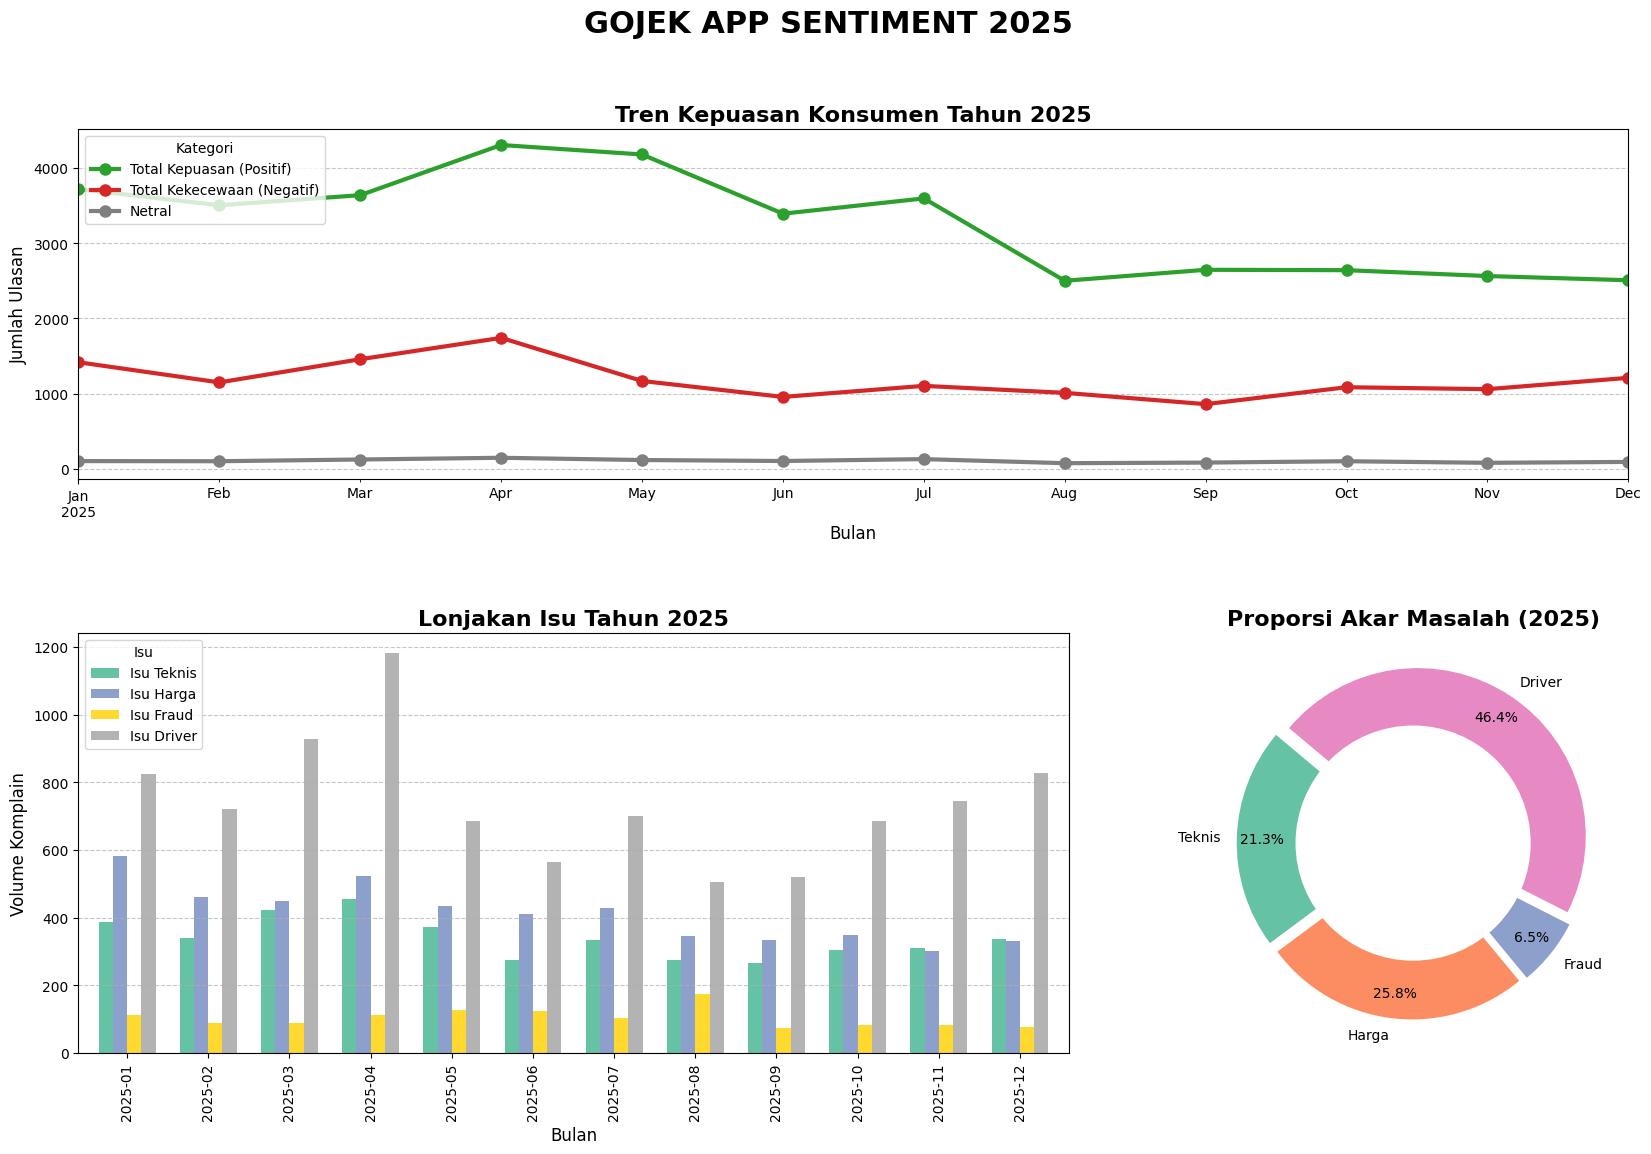

                    SUMMARY & KPI SCORECARDS 2025                     
Total Ulasan Dianalisis : 54660 ulasan
Tingkat Kepuasan        : 71.7% (Didominasi Sentimen Positif)
Isu Terbesar Saat Ini   : Isu Driver (Kasar/Nyasar) dengan 8895 komplain
Risiko Fintech (Fraud)  : Ditemukan 1249 keluhan terkait saldo/akun!

[INSPEKSI DATA] 3 Ulasan Paling Kritis (Sarkasme/Fraud) Bulan Ini:


,at,score,content,score_label
7688,2025-12-01,1,"payah bgt dah saya dulu driver di gojek, dan p...",Negatif (Kritis)
7693,2025-12-01,1,kenapa ya skg cari driver food susah area sema...,Negatif (Kritis)
7697,2025-12-01,1,"gila ga ngotak banget, pulang kerja yg biasany...",Negatif (Kritis)


In [112]:
#VISUALISASI
import seaborn as sns

# 1. PERSIAPAN DATA KPI (Scorecard)
total_ulasan = len(df_2025)
total_positif = len(df_2025[df_2025['score_label'].str.contains('Positif', na=False)])
persentase_puas = (total_positif / total_ulasan) * 100 if total_ulasan > 0 else 0

total_isu = {
    'Isu Teknis (Bug/Error)': len(df_teknis),
    'Isu Harga (Mahal/Ongkir)': len(df_harga),
    'Isu Fraud (Saldo/Hack)': len(df_fraud),
    'Isu Driver (Kasar/Nyasar)': len(df_driver)
}
isu_tertinggi = max(total_isu, key=total_isu.get)

# 2. SETUP LAYOUT DASHBOARD (2 Baris, 3 Kolom)
fig = plt.figure(figsize=(20, 12))
gs = plt.GridSpec(2, 3, figure=fig, height_ratios=[1, 1.2], wspace=0.3, hspace=0.4)
fig.suptitle('GOJEK APP SENTIMENT 2025', fontsize=22, fontweight='bold', y=0.98)

# --- GRAFIK 1 (ATAS): TREN KEPUASAN (LINE CHART) ---
ax_line = fig.add_subplot(gs[0, :])

# Membuat DataFrame sementara untuk menggabungkan (Roll-up) sentimen
laporan_tren = pd.DataFrame()
laporan_tren['Total Kepuasan (Positif)'] = laporan_bulanan.get('Positif', 0) + laporan_bulanan.get('Positif (Apresiasi)', 0)
laporan_tren['Total Kekecewaan (Negatif)'] = laporan_bulanan.get('Negatif', 0) + laporan_bulanan.get('Negatif (Kritis)', 0)
laporan_tren['Netral'] = laporan_bulanan.get('Netral', 0)

# Plot dengan warna yang memiliki arti psikologis
warna_kustom = ['#2ca02c', '#d62728', '#7f7f7f'] # Hijau, Merah, Abu-abu
laporan_tren.plot(kind='line', marker='o', linewidth=3, markersize=8, ax=ax_line, color=warna_kustom)

ax_line.set_title('Tren Kepuasan Konsumen Tahun 2025', fontsize=16, fontweight='bold')
ax_line.set_xlabel('Bulan', fontsize=12)
ax_line.set_ylabel('Jumlah Ulasan', fontsize=12)
ax_line.grid(axis='y', linestyle='--', alpha=0.7)
ax_line.legend(title='Kategori', loc='upper left')

# --- GRAFIK 2 (BAWAH KIRI): LONJAKAN ISU BISNIS (BAR CHART) ---
ax_bar = fig.add_subplot(gs[1, :2])
kolom_isu = ['Isu Teknis', 'Isu Harga', 'Isu Fraud', 'Isu Driver']
laporan_bulanan[[col for col in kolom_isu if col in laporan_bulanan.columns]].plot(kind='bar', ax=ax_bar, colormap='Set2', width=0.7)
ax_bar.set_title('Lonjakan Isu Tahun 2025', fontsize=16, fontweight='bold')
ax_bar.set_xlabel('Bulan', fontsize=12)
ax_bar.set_ylabel('Volume Komplain', fontsize=12)
ax_bar.grid(axis='y', linestyle='--', alpha=0.7)
ax_bar.legend(title='Isu', loc='upper left')

# --- GRAFIK 3 (BAWAH KANAN): PROPORSI ISU (DONUT CHART) ---
ax_donut = fig.add_subplot(gs[1, 2])
labels = [k.split(' ')[1] for k in total_isu.keys()] # Ambil nama pendeknya saja
sizes = list(total_isu.values())
colors = sns.color_palette('Set2')[0:len(labels)]

# Bikin bentuk Donut (Bukan Pie biasa)
wedges, texts, autotexts = ax_donut.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85, explode=[0.05]*len(labels))
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax_donut.add_patch(centre_circle)
ax_donut.set_title('Proporsi Akar Masalah (2025)', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- 3. PRINT KPI SCORECARDS ---
print("SUMMARY & KPI SCORECARDS 2025".center(70))
print("="*70)
print(f"Total Ulasan Dianalisis : {total_ulasan} ulasan")
print(f"Tingkat Kepuasan        : {persentase_puas:.1f}% (Didominasi Sentimen Positif)")
print(f"Isu Terbesar Saat Ini   : {isu_tertinggi} dengan {total_isu[isu_tertinggi]} komplain")
print(f"Risiko Fintech (Fraud)  : Ditemukan {total_isu['Isu Fraud (Saldo/Hack)']} keluhan terkait saldo/akun!")
print("="*70)

# Menampilkan Sampel Ulasan Paling Kritis (Drill-Down)
print("\n[INSPEKSI DATA] 3 Ulasan Paling Kritis (Sarkasme/Fraud) Bulan Ini:")
df_kritis = df_2025[(df_2025['score_label'] == 'Negatif (Kritis)') | (df_2025['content'].str.contains('saldo|hilang|hack', na=False))]
display(df_kritis[['at', 'score', 'content', 'score_label']].head(3))

In [115]:
#  BUKTI CLOSURE (KLASIFIKASI DINAMIS)

df_demo = df_clean.head(5).copy()

# Mencetak fungsi baru dengan aturan berbeda dari HOF buat_klasifikator_sentimen
klasifikator_standar = buat_klasifikator_sentimen(batas_bawah=2, batas_atas=4) # Standar
klasifikator_ketat   = buat_klasifikator_sentimen(batas_bawah=3, batas_atas=5) # Ketat

# Eksekusi pengujian (.apply adalah Higher-Order Function)
df_demo['Standar'] = df_demo['score'].apply(klasifikator_standar)
df_demo['Ketat']   = df_demo['score'].apply(klasifikator_ketat)

print("PEMBUKTIAN CLOSURE BERHASIL!")
print("Membandingkan dua aturan sentimen yang dicetak dari SATU fungsi Induk:")
display(df_demo[['content', 'score', 'Standar', 'Ketat']])

PEMBUKTIAN CLOSURE BERHASIL!
Membandingkan dua aturan sentimen yang dicetak dari SATU fungsi Induk:


,content,score,Standar,Ketat
0,ok bgt aplikasinya membantu sy pas lg lapar sk...,5,Positif,Positif
1,"aku udah ke sekian kali ga sengaja ke order, t...",3,Netral,Negatif
2,sangat membantu,5,Positif,Positif
3,"jangan di download ya guyss, mentang mentang a...",1,Negatif,Negatif
4,good,5,Positif,Positif


TESTING

In [102]:
import pandas.testing as pd_testing

In [98]:
print("[TEST 1] Memeriksa Immutability & Struktur Data")
try:
    assert df.shape[1] == 11, "Kolom Data Mentah berubah!"
    assert df_clean.shape[1] == 12, "Kolom Data Clean tidak sesuai (harusnya bertambah 1 kolom label)!"
    try:
        pd_testing.assert_frame_equal(df, df_clean)
        print("⚠️ Warning: Data mentah & clean identik (Cleaning gagal?)")
    except AssertionError:
        print("✅ PASS: Immutability Terjaga (Data Clean adalah entitas baru).")
except AssertionError as e: print(f"❌ FAIL: {e}")


[TEST 1] Memeriksa Immutability & Struktur Data
✅ PASS: Immutability Terjaga (Data Clean adalah entitas baru).


In [99]:
print("\n[TEST 2] Memeriksa Pure Function (Cleaning Teks)")
try:
    assert bersihkan_teks("  GOJEK Error Banget!!  ") == "gojek error banget!!"
    print("✅ PASS: Fungsi Cleaning Berjalan Benar.")
except AssertionError: print("❌ FAIL: Logika cleaning teks salah.")


[TEST 2] Memeriksa Pure Function (Cleaning Teks)
✅ PASS: Fungsi Cleaning Berjalan Benar.


In [100]:
print("\n[TEST 3] Memeriksa Closure (Filter Dinamis)")
try:
    filter_a = buat_filter_keyword('bagus')
    filter_b = buat_filter_keyword('jelek')
    assert filter_a is not filter_b
    print("✅ PASS: Factory berhasil membuat fungsi filter independen.")
except AssertionError: print("❌ FAIL: Fungsi filter konflik (objek sama).")



[TEST 3] Memeriksa Closure (Filter Dinamis)
✅ PASS: Factory berhasil membuat fungsi filter independen.


In [101]:
print("\n[TEST 4] Memeriksa Logika Sentimen (Dinamis)")
try:
    f_std = buat_klasifikator_sentimen(2, 4)
    f_ketat = buat_klasifikator_sentimen(3, 5)
    assert f_std(3) == 'Netral'
    assert f_ketat(3) == 'Negatif'
    print("✅ PASS: Logika klasifikasi dinamis valid.")
except AssertionError: print("❌ FAIL: Logika sentimen tidak sesuai aturan.")


[TEST 4] Memeriksa Logika Sentimen (Dinamis)
✅ PASS: Logika klasifikasi dinamis valid.
